In [ ]:
!pip install opencv-python-headless
!pip install scikit-learn
!pip install efficientnet
!pip install innvestigate

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import glob

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,roc_auc_score, f1_score,confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.backend
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, GlobalAveragePooling2D

tf.compat.v1.disable_eager_execution()

import innvestigate
import innvestigate.utils as iutils

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# paths
faceforensis_real_path = "/kaggle/input/faceforensics-face/REAL"
faceforensis_fake_deepfake = "/kaggle/input/faceforensics-face/Deepfake"
faceforensis_fake_deepfakedetection = "/kaggle/input/faceforensics-face/DeepfakeDetection"
faceforensis_fake_face2face = "/kaggle/input/faceforensics-face/Face2Face"
faceforensis_fake_faceshifter = "/kaggle/input/faceforensics-face/FaceShifter"
faceforensis_fake_faceswap = "/kaggle/input/faceforensics-face/FaceSwap"
faceforensis_fake_neuraltextures = "/kaggle/input/faceforensics-face/NeuralTextures"

# models
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
eff_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

16705208/16705208 [==============================] - 0s 0us/step


In [4]:
import innvestigate.utils.visualizations as ivis

# Handle input depending on model and backend.
channels_first = keras.backend.image_data_format() == "channels_first"
color_conversion = "BGRtoRGB"  # keras.applications use BGR format

def postprocess(X, color_conversion, channels_first):
    X = X.copy()
    X = iutils.postprocess_images(
        X, color_coding=color_conversion, channels_first=channels_first
    )
    return X

def heatmap(X):
    # X = ivis.gamma(X, minamp=0, gamma=0.95)
    return ivis.heatmap(X)

In [5]:
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["REAL", "FAKE"])
    plt.figure(figsize=(5, 5))
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

In [6]:
def extract_features_from_image(image_path): 
    # Verifica se o arquivo é uma imagem válida
    if not os.path.isfile(image_path):
        print(f"[ERRO] O arquivo {image_path} não é válido ou não é uma imagem.")
        return None

    # Carrega a imagem
    img = cv2.imread(image_path)
    if img is None:
        print(f"[ERRO] Não foi possível carregar a imagem {image_path}.")
        return None

    # Redimensiona a imagem
    img_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # Processamento para VGG, ResNet e EfficientNet
    img_batch_vgg = preprocess_vgg(np.expand_dims(img_rgb.astype('float32'), axis=0))
    img_batch_resnet = preprocess_resnet(np.expand_dims(img_rgb.astype('float32'), axis=0))
    img_batch_eff = preprocess_eff(np.expand_dims(img_rgb.astype('float32'), axis=0))

    vgg_feat = vgg_model.predict(img_batch_vgg, verbose=0).flatten()
    res_feat = resnet_model.predict(img_batch_resnet, verbose=0).flatten()
    eff_feat = eff_model.predict(img_batch_eff, verbose=0).flatten()

    combined = np.concatenate([vgg_feat, res_feat, eff_feat])

    return combined  # Retorne a combinação das features

def generate_model(real_path, fake_path):
    X_train, y_train = [], []
    X_test, y_test = [], []

    for label, path in [("REAL", real_path), ("FAKE", fake_path)]:
        image_files = os.listdir(path)
        test_files = image_files[:50]
        train_files = image_files[50:]

        for image_name in tqdm(test_files, desc=f"{label} (TESTE)"):
            image_path = os.path.join(path, image_name)
            feat = extract_features_from_image(image_path)
            if feat is not None:
                X_test.append(feat)
                y_test.append(0 if label == "REAL" else 1)
            else:
                print(f"[INFO] Não foram extraídas características de {image_path}")

        for image_name in tqdm(train_files, desc=f"{label} (TREINO)"):
            image_path = os.path.join(path, image_name)
            feat = extract_features_from_image(image_path)
            if feat is not None:
                X_train.append(feat)
                y_train.append(0 if label == "REAL" else 1)
            else:
                print(f"[INFO] Não foram extraídas características de {image_path}")

    if len(X_train) == 0 or len(X_test) == 0:
        print("Erro: Não foram extraídas características suficientes para o treino ou teste.")
        return None, None

    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # PCA + SVM
    pca = PCA(n_components=10)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    svm = SVC(kernel='linear')
    svm.fit(X_train_pca, y_train)

    y_pred = svm.predict(X_test_pca)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))

    if hasattr(svm, "decision_function"):
        y_scores = svm.decision_function(X_test_pca)
        auc = roc_auc_score(y_test, y_scores)
        print("AUC:", auc)
    else:
        print("O modelo SVM não possui decision_function para calcular a AUC.")

    print("Classification Report:\n", classification_report(y_test, y_pred))

    return svm, pca

In [7]:
# Chamada da função
print("Deepfake")
svm_deepfake, pca_deepfake = generate_model(faceforensis_real_path, faceforensis_fake_deepfake)
print("DeepfakeDetection")
svm_deepfakedetection, pca_deepfakedetection = generate_model(faceforensis_real_path, faceforensis_fake_deepfakedetection)
print("Face2Face")
svm_face2face, pca_face2face = generate_model(faceforensis_real_path, faceforensis_fake_face2face)
print("FaceShifter")
svm_faceshifter, pca_faceshifter = generate_model(faceforensis_real_path, faceforensis_fake_faceshifter)
print("FaceSwap")
svm_faceswap, pca_faceswap = generate_model(faceforensis_real_path, faceforensis_fake_faceswap)
print("NeuralTextures")
svm_neuratextures, pca_neuratextures = generate_model(faceforensis_real_path, faceforensis_fake_neuraltextures)

Deepfake


REAL (TESTE):   0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/keras/src/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
FAKE (TREINO): 100%|██████████| 200/200 [01:31<00:00,  2.18it/s]


Accuracy: 0.69
F1-score (macro): 0.6874684948079444
AUC: 0.7464
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.78      0.72        50
           1       0.73      0.60      0.66        50

    accuracy                           0.69       100
   macro avg       0.70      0.69      0.69       100
weighted avg       0.70      0.69      0.69       100

DeepfakeDetection


FAKE (TREINO): 100%|██████████| 200/200 [01:31<00:00,  2.18it/s]


Accuracy: 0.96
F1-score (macro): 0.9599358974358974
AUC: 0.9852000000000001
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        50
           1       0.93      1.00      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

Face2Face


...

Accuracy: 0.47
F1-score (macro): 0.46567194273616297
AUC: 0.48560000000000003
Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.38      0.42        50
           1       0.47      0.56      0.51        50

    accuracy                           0.47       100
   macro avg       0.47      0.47      0.47       100
weighted avg       0.47      0.47      0.47       100

FaceSwap


FAKE (TREINO): 100%|██████████| 200/200 [01:32<00:00,  2.15it/s]


Accuracy: 0.53
F1-score (macro): 0.5288220551378446
AUC: 0.49279999999999996
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.58      0.55        50
           1       0.53      0.48      0.51        50

    accuracy                           0.53       100
   macro avg       0.53      0.53      0.53       100
weighted avg       0.53      0.53      0.53       100

NeuralTextures


FAKE (TREINO): 100%|██████████| 200/200 [01:32<00:00,  2.16it/s]


Accuracy: 0.42
F1-score (macro): 0.4162640901771337
AUC: 0.4476
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.34      0.37        50
           1       0.43      0.50      0.46        50

    accuracy                           0.42       100
   macro avg       0.42      0.42      0.42       100
weighted avg       0.42      0.42      0.42       100



In [8]:
# Adiciona pooling e uma camada densa com softmax
def add_pooling(model):
    x = model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(2, activation='softmax')(x)
    # Novo modelo com softmax no final
    model = Model(inputs=model.input, outputs=output)
    
    # Agora podemos usar o innvestigate
    return innvestigate.model_wo_softmax(model)

model_wo_softmax_vgg = add_pooling(vgg_model)
model_wo_softmax_res = add_pooling(resnet_model)
model_wo_softmax_eff = add_pooling(eff_model)

In [9]:
from tensorflow.keras.preprocessing.image import load_img
# Image titles
image_titles = ['FRAME 1', 'FRAME 2', 'FRAME 3', 'FRAME 4', 'FRAME 5']

# Alterar o caminho da imagem com os 5 frames
img1 = load_img('/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame1.jpg', target_size=(224, 224))
img2 = load_img('/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame2.jpg', target_size=(224, 224))
img3 = load_img('/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame3.jpg', target_size=(224, 224))
img4 = load_img('/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame4.jpg', target_size=(224, 224))
img5 = load_img('/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame5.jpg', target_size=(224, 224))
images = np.asarray([np.array(img1), np.array(img2), np.array(img3), np.array(img4), np.array(img5)])

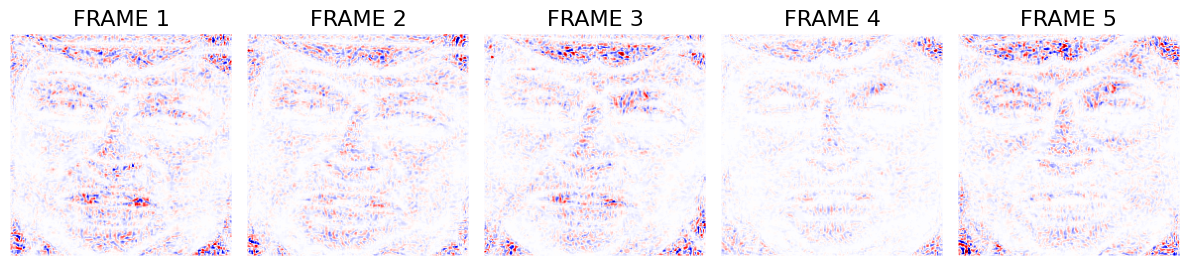

In [11]:
analyzer = innvestigate.create_analyzer(
            "lrp.z",  # Pode alterar esse método do innvestigate
            model_wo_softmax_vgg,  # model without softmax output
        )  # optional analysis parameters
f, ax = plt.subplots(nrows=1, ncols=5, figsize=(12, 4))
for i, title in enumerate(image_titles):
    x = images[i]
    x = x[None, :, :, :]
    x_pp = preprocess_vgg(x)
    a = analyzer.analyze(x_pp)
    # Apply common postprocessing, e.g., re-ordering the channels for plotting.
    a = postprocess(a, color_conversion, channels_first)
    # Apply analysis postprocessing, e.g., creating a heatmap.
    a_hp = heatmap(a)
    
    ax[i].set_title(title, fontsize=16)
    ax[i].imshow(a_hp[0])
    ax[i].axis('off')
plt.tight_layout()
plt.show()